<a href="https://colab.research.google.com/github/madanjha/PythonDS/blob/main/NumpaySP500_company.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/sp500_companies.csv')

In [ ]:
df

,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,148.03,2354875990016,1.305410e+11,0.081,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.064857
1,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software—Infrastructure,255.14,1915585953792,9.798300e+10,0.124,Redmond,WA,United States,221000.0,"Microsoft Corporation develops, licenses, and ...",0.052759
2,NMS,GOOG,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,101.45,1311241142272,9.373300e+10,0.061,Mountain View,CA,United States,186779.0,Alphabet Inc. provides various products and pl...,0.036114
3,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,100.99,1308729278464,9.373300e+10,0.061,Mountain View,CA,United States,186779.0,Alphabet Inc. provides various products and pl...,0.036045
4,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,96.54,984872189952,5.154900e+10,0.147,Seattle,WA,United States,1544000.0,"Amazon.com, Inc. engages in the retail sale of...",0.027125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,NYQ,ALK,"Alaska Air Group, Inc.","Alaska Air Group, Inc.",Industrials,Airlines,47.44,6017194496,1.092000e+09,0.448,Seattle,WA,United States,22354.0,"Alaska Air Group, Inc., through its subsidiari...",0.000166
491,NYQ,LUMN,"Lumen Technologies, Inc.","Lumen Technologies, Inc.",Communication Services,Telecom Services,5.47,5600677888,7.419000e+09,-0.063,Monroe,LA,United States,35000.0,"Lumen Technologies, Inc., a facilities-based t...",0.000154
492,NMS,NWL,Newell Brands Inc.,Newell Brands Inc.,Consumer Defensive,Household & Personal Products,12.97,5517437952,1.390000e+09,-0.065,Atlanta,GA,United States,32000.0,"Newell Brands Inc. designs, manufactures, sour...",0.000152
493,NYQ,VNO,Vornado Realty Trust,Vornado Realty Trust,Real Estate,REIT—Office,25.29,4847612416,8.506830e+08,0.168,New York,NY,United States,3224.0,Vornado's portfolio is concentrated in the nat...,0.000134


In [ ]:
print(df.isnull().sum())

Exchange                0
Symbol                  0
Shortname               0
Longname                0
Sector                  0
Industry                0
Currentprice            0
Marketcap               0
Ebitda                 42
Revenuegrowth          12
City                    0
State                  20
Country                 0
Fulltimeemployees       5
Longbusinesssummary     0
Weight                  0
dtype: int64


In [ ]:
# Method 1: Total null count
total_nulls = df.isnull().sum().sum()
print(f"Total null values: {total_nulls}")

# Method 2: Boolean matrix (True = null)
null_mask = df.isnull()
print(null_mask)

# Method 3: Rows with any nulls
rows_with_nulls = df.isnull().any(axis=1).sum()
print(f"Rows with nulls: {rows_with_nulls}")

Total null values: 79
     Exchange  Symbol  Shortname  Longname  Sector  Industry  Currentprice  \
0       False   False      False     False   False     False         False   
1       False   False      False     False   False     False         False   
2       False   False      False     False   False     False         False   
3       False   False      False     False   False     False         False   
4       False   False      False     False   False     False         False   
..        ...     ...        ...       ...     ...       ...           ...   
490     False   False      False     False   False     False         False   
491     False   False      False     False   False     False         False   
492     False   False      False     False   False     False         False   
493     False   False      False     False   False     False         False   
494     False   False      False     False   False     False         False   

     Marketcap  Ebitda  Revenuegrowth   C

Let's visualize the distribution of companies across different sectors in the S&P 500.

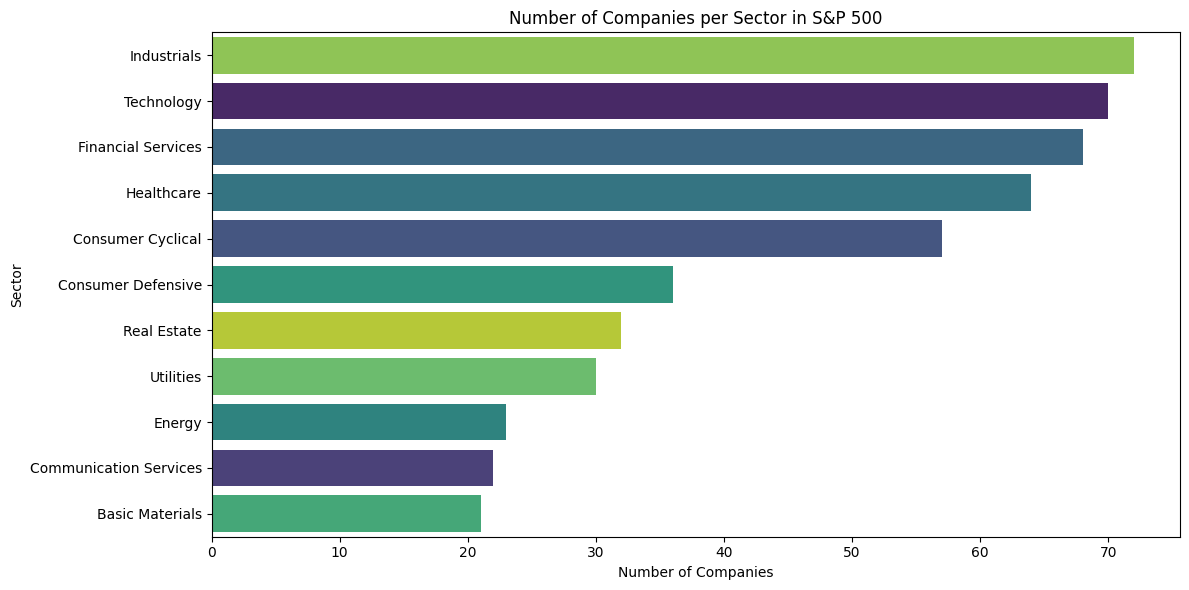

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(y='Sector', data=df, order=df['Sector'].value_counts().index, palette='viridis', hue='Sector', legend=False)
plt.title('Number of Companies per Sector in S&P 500')
plt.xlabel('Number of Companies')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

Need to find company has the highest marketcap?

In [ ]:
# Find the company with the highest Currentprice
highest_currentprice_company = df.loc[df['Currentprice'].idxmax()]

print("Company with the highest Currentprice:")
print(highest_currentprice_company[['Shortname', 'Longname', 'Currentprice']])

Company with the highest Currentprice:
Shortname       NVR, Inc.
Longname        NVR, Inc.
Currentprice      4639.01
Name: 375, dtype: object


In [ ]:
# Find the company with the highest Marketcap
highest_marketcap_company = df.loc[df['Marketcap'].idxmax()]

print("Company with the highest Marketcap:")
print(highest_marketcap_company[['Shortname', 'Longname', 'Marketcap']])

Company with the highest Marketcap:
Shortname       Apple Inc.
Longname        Apple Inc.
Marketcap    2354875990016
Name: 0, dtype: object


In [ ]:
# Calculate the minimum and maximum revenue growth
min_revenue_growth = df['Revenuegrowth'].min()
max_revenue_growth = df['Revenuegrowth'].max()

print(f"Minimum Revenue Growth: {min_revenue_growth:.4f}")
print(f"Maximum Revenue Growth: {max_revenue_growth:.4f}")
print(f"Range of Revenue Growth: {max_revenue_growth - min_revenue_growth:.4f}")

Minimum Revenue Growth: -0.4440
Maximum Revenue Growth: 270.7910
Range of Revenue Growth: 271.2350


In [ ]:
# Filter for companies with more than 2,000,000 full-time employees
high_employee_companies = df[df['Fulltimeemployees'] > 2000000]

# Display the relevant information for these companies
if not high_employee_companies.empty:
    print("Companies with more than 2,000,000 full-time employees:")
    print(high_employee_companies[['Shortname', 'Longname', 'Fulltimeemployees']])
else:
    print("No companies found with more than 2,000,000 full-time employees.")

Companies with more than 2,000,000 full-time employees:
      Shortname      Longname  Fulltimeemployees
9  Walmart Inc.  Walmart Inc.          2300000.0


In [ ]:
# Count the number of companies per state
state_counts = df['State'].value_counts()

# Find the state with the most companies
most_companies_state = state_counts.idxmax()
num_companies = state_counts.max()

print(f"The state with the most S&P 500 companies is {most_companies_state} with {num_companies} companies.")

The state with the most S&P 500 companies is CA with 66 companies.


In [ ]:
# Filter companies with revenue growth greater than 0.1
companies_with_high_growth = df[df['Revenuegrowth'] > 0.1]

# Find the company with the lowest current price among the filtered companies
if not companies_with_high_growth.empty:
    lowest_price_high_growth_company = companies_with_high_growth.loc[companies_with_high_growth['Currentprice'].idxmin()]

    print("Company with the lowest Currentprice among those with Revenuegrowth > 0.1:")
    print(lowest_price_high_growth_company[['Shortname', 'Longname', 'Currentprice', 'Revenuegrowth']])
else:
    print("No companies found with Revenuegrowth greater than 0.1.")

Company with the lowest Currentprice among those with Revenuegrowth > 0.1:
Shortname              Carnival Corporation
Longname         Carnival Corporation & plc
Currentprice                           9.93
Revenuegrowth                         6.886
Name: 420, dtype: object


In [ ]:
# Filter companies located in California
california_companies = df[df['State'] == 'CA']

# Count the number of companies per sector in California
sector_counts_ca = california_companies['Sector'].value_counts()

# Find the sector with the most companies in California
most_companies_sector_ca = sector_counts_ca.idxmax()
num_companies_sector_ca = sector_counts_ca.max()

print(f"The sector with the most S&P 500 companies in California is '{most_companies_sector_ca}' with {num_companies_sector_ca} companies.")

The sector with the most S&P 500 companies in California is 'Technology' with 27 companies.


In [ ]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Get correlations with 'Marketcap'
marketcap_correlations = correlation_matrix['Marketcap'].drop('Marketcap')

# Find the feature with the highest absolute correlation
highest_correlated_feature = marketcap_correlations.abs().idxmax()
highest_correlation_value = marketcap_correlations[highest_correlated_feature]

print(f"The feature most highly correlated with Marketcap is '{highest_correlated_feature}' with a correlation of {highest_correlation_value:.4f}.")

The feature most highly correlated with Marketcap is 'Weight' with a correlation of 1.0000.
